In [28]:
# === System & OS Utilities ===
import os
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.ERROR)

# === Progress Bar ===
from tqdm import tqdm

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.layers import (
    Conv2D, Dense, Layer,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Add, Reshape, Multiply, Activation, Concatenate
)

import os
import numpy as np
from tensorflow.keras import layers, Model, initializers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# === Data Handling ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# === Scikit-learn ===
from sklearn.model_selection import train_test_split

from scipy import stats
from scipy.ndimage import gaussian_filter

In [29]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected: {len(gpus)}")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPUs detected.")

GPUs detected: 1


In [30]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCH = 100
img_shape=(*IMG_SIZE,3)
dataset_path = r"/Users/faysalahmmed/Downloads/PBS-3242-Normalized-datasets/Segmented_Dataset/Masked_Images"
labels = sorted([d for d in os.listdir(dataset_path) 
                 if os.path.isdir(os.path.join(dataset_path, d))])
print("Class Names:", labels)

Class Names: ['Benign', 'Early Pre-B', 'Pre-B', 'Pro-B']


In [31]:
def data_frame(path):
    class_paths = []
    classes = []

    for label in os.listdir(path):
        class_dir = os.path.join(path, label)
        if os.path.isdir(class_dir):  
            for image in os.listdir(class_dir):
                class_paths.append(os.path.join(class_dir, image))
                classes.append(label)

    df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return df

In [32]:
dataframe = data_frame(dataset_path)
# First split: 70% train, 30% temp (val + test)
train_dataframe, temp_dataframe = train_test_split(
    dataframe,
    test_size=0.3,
    random_state=42,
    stratify=dataframe['Class']
)

# Second split: 2/3 val, 1/3 test of the 30% => 20% val, 10% test overall
validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe,
    test_size=1/3,
    random_state=42,
    stratify=temp_dataframe['Class']
)

print(f"Train size: {len(train_dataframe)}, Validation size: {len(validation_dataframe)}, Test size: {len(test_dataframe)}")

Train size: 5600, Validation size: 1600, Test size: 800


In [33]:
def preprocess_image(image):
    """
    Simple Min-Max Normalization for RGB image.
    Safe for Keras ImageDataGenerator (expects one image at a time).
    Returns float32 image scaled to [0, 1].
    """
    image = image.astype(np.float32)

    min_val = image.min()
    max_val = image.max()

    # avoid division by zero
    if max_val - min_val < 1e-6:
        return np.zeros_like(image, dtype=np.float32)

    # min-max scale to [0, 1]
    image = (image - min_val) / (max_val - min_val)

    return image


In [34]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,  # CLAHE preprocessing
    rotation_range=180,          # lesions can be at any orientation
    zoom_range=0.1,              # up to ±10% zoom
    width_shift_range=0.10,      # up to 10% horizontal shift
    height_shift_range=0.10,     # up to 10% vertical shift
    shear_range=0.05,            # very small shear (avoid heavy distortion)
    horizontal_flip=True,        # horizontal flipping image
    vertical_flip=True,          # vertically flipping image
    brightness_range=[0.9, 1.1], # ±10% brightness variation
    fill_mode='nearest',        
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)


train_data = train_datagen.flow_from_dataframe(train_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, seed=42)

validation_data = val_datagen.flow_from_dataframe(validation_dataframe, x_col='Class Path',
                                     y_col='Class', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE, seed=42)

test_data = test_datagen.flow_from_dataframe(test_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, shuffle=False, seed=42)

Found 5600 validated image filenames belonging to 4 classes.
Found 1600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [35]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="F1Score")
class F1Score(tf.keras.metrics.Metric):
    """
    Custom Keras metric to compute the F1 Score.
    The F1 score is the harmonic mean of precision and recall.
    """

    def __init__(self, name='f1_score', **kwargs):
        """
        Initializes the F1Score metric. 
        - Uses Keras' Precision and Recall metrics as intermediate steps.
        """
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()  # Precision metric
        self.recall = tf.keras.metrics.Recall()  # Recall metric

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        Updates the state of the metric.
        - This method is called during training to update precision and recall.
        - The precision and recall states are updated based on true and predicted values.
        """
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        """
        Computes and returns the F1 score.
        - F1 score is calculated as the harmonic mean of precision and recall.
        - Prevents division by zero by adding a small epsilon value to the denominator.
        """
        p = self.precision.result()  # Get precision value
        r = self.recall.result()  # Get recall value
        return 2 * (p * r) / (p + r + tf.keras.backend.epsilon())  # Calculate F1 score

    def reset_states(self):
        """
        Resets the states of the precision and recall metrics.
        - This is called at the beginning of each epoch.
        """
        self.precision.reset_states()  # Reset precision state
        self.recall.reset_states()  # Reset recall state


In [36]:
######## Main Model which is used in this study of breast cancer###########
@register_keras_serializable(package="Custom", name="KANLayer")
class KANLayer(Layer):
    def __init__(self, units, grid=5, spline_order=3, dropout=0.0, **kwargs):
        """
        KANLayer: Kernel Attention Network Layer (self-explainable)
        - units: output dimension
        - grid: number of spline bins
        - spline_order: reserved for higher-order splines
        - dropout: dropout rate
        """
        super(KANLayer, self).__init__(**kwargs)
        self.units = int(units)
        self.grid = int(grid)
        self.spline_order = int(spline_order)
        self.dropout = float(dropout)

    def build(self, input_shape):
        if len(input_shape) != 2:
            raise ValueError(f"KANLayer expects 2D input (batch, features). Got shape: {input_shape}")

        input_dim = int(input_shape[-1])

        # Linear weights (like Dense)
        self.w = self.add_weight(
            shape=(input_dim, self.units),
            initializer=initializers.HeNormal(),
            trainable=True,
            name="linear_weight"
        )

        # Spline weights: (grid, input_dim, units)
        self.spline_w = self.add_weight(
            shape=(self.grid, input_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="spline_weight"
        )

        # Bias
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )

        super(KANLayer, self).build(input_shape)

    def call(self, inputs, training=False):
        x = tf.cast(inputs, tf.float32)

        # --- Linear part ---
        linear_out = tf.linalg.matmul(x, self.w)

        # --- Spline / soft-binning part ---
        x_exp = tf.expand_dims(x, axis=1)  # (B, 1, D)

        # Fixed 0-1 grid (assumes input normalized to 0-1)
        grid_centers = tf.linspace(0.0, 1.0, self.grid)
        grid_centers = tf.reshape(grid_centers, (1, self.grid, 1))  # (1, grid, 1)
        grid_centers = tf.cast(grid_centers, tf.float32)

        # Soft RBF-like basis: (B, grid, D)
        spline_basis = tf.exp(-tf.square(x_exp - grid_centers))

        # einsum: "bgd,gdu->bu" -> (B, units)
        spline_out = tf.einsum("bgd,gdu->bu", spline_basis, self.spline_w)

        out = linear_out + spline_out + self.b

        if self.dropout and training:
            out = tf.nn.dropout(out, rate=self.dropout)

        return out

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

    def get_config(self):
        cfg = super(KANLayer, self).get_config()
        cfg.update({
            "units": self.units,
            "grid": self.grid,
            "spline_order": self.spline_order,
            "dropout": self.dropout,
        })
        return cfg
    
# Channel Attention Block
@tf.keras.utils.register_keras_serializable(package="Custom", name="ChannelAttention")
class ChannelAttention(Layer):
    """
    Channel Attention Block (CA) that computes channel-wise attention.
    
    Args:
        reduction: The factor for reducing the number of channels in the intermediate layer.
    """
    def __init__(self, reduction=16, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        """
        Build the dense layers for the Channel Attention mechanism.
        - `shared_dense_one`: reduces channel dimensions.
        - `shared_dense_two`: restores the original channel dimensions.
        """
        channel = input_shape[-1]  # Number of channels in the input tensor
        self.shared_dense_one = Dense(channel // self.reduction, activation='relu', kernel_initializer='he_normal', use_bias=True)
        self.shared_dense_two = Dense(channel, kernel_initializer='he_normal', use_bias=True)

    def call(self, inputs):
        """
        Apply the Channel Attention mechanism:
        - Global Average Pooling (avg_pool) and Global Max Pooling (max_pool)
        - Process each through a set of shared dense layers.
        - Combine both attentions and apply a sigmoid function to get the attention weights.
        """
        # Global average and max pooling
        avg_pool = GlobalAveragePooling2D()(inputs)
        max_pool = GlobalMaxPooling2D()(inputs)

        # Apply shared dense layers for both average and max pooled features
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)

        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)

        # Combine both attention signals and apply sigmoid activation
        attention = Add()([avg_pool, max_pool])
        attention = Activation('sigmoid')(attention)

        # Reshape the attention to match the input dimensions and apply multiplication
        attention = Reshape((1, 1, -1))(attention)
        return Multiply()([inputs, attention])

# Spatial Attention Block
@tf.keras.utils.register_keras_serializable(package="Custom", name="SpatialAttention")
class SpatialAttention(Layer):
    """
    Spatial Attention Block (SA) that computes spatial attention across channels.
    """
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        # 2D convolution for spatial attention with a kernel size of 7x7 and sigmoid activation
        self.conv2d = Conv2D(filters=1, kernel_size=7, strides=1, padding='same', activation='sigmoid')

    def call(self, inputs):
        """
        Apply the Spatial Attention mechanism:
        - Apply both average and max pooling across the channel axis to extract spatial features.
        - Concatenate the two features and apply convolution to get spatial attention.
        """
        # Apply global average and max pooling along the channel axis
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)

        # Concatenate both pooled features
        concat = Concatenate(axis=-1)([avg_pool, max_pool])

        # Apply convolution to compute spatial attention map
        attention = self.conv2d(concat)

        # Multiply the attention map with the input to highlight important spatial features
        return Multiply()([inputs, attention])

# Full CBAM Block
def cbam_block(inputs, reduction=16):
    """
    CBAM (Convolutional Block Attention Module) that sequentially applies
    Channel Attention and Spatial Attention blocks.

    Args:
        inputs: Input tensor to the CBAM block.
        reduction: The factor for reducing the channel dimension in the Channel Attention block.
    
    Returns:
        The output tensor after applying both attention mechanisms.
    """
    # Apply Channel Attention followed by Spatial Attention
    x = ChannelAttention(reduction)(inputs)
    x = SpatialAttention()(x)
    return x

# ----------------------------
# Custom Keras Layer for Res2 Split
# ----------------------------
@register_keras_serializable(package="Custom", name="Res2Split")
class Res2Split(layers.Layer):
    def __init__(self, scale, **kwargs):
        super().__init__(**kwargs)
        self.scale = scale

    def call(self, x):
        channels = tf.shape(x)[-1]
        chunk = channels // self.scale
        splits = []
        for i in range(self.scale):
            splits.append(x[:, :, :, i*chunk:(i+1)*chunk])
        return splits

In [37]:
model = load_model('Proposed Model/Proposed_Model.keras')  

In [38]:
# ================= Grad-CAM++ Class =================
class GradCAMPlusPlus:
    def __init__(self, model, target_layer, labels):
        self.model = model
        self.labels = labels
        try:
            self.target_layer = model.get_layer(target_layer)
        except:
            print(f"❌ Layer '{target_layer}' not found!")
            print(f"Available Conv layers: {[l.name for l in model.layers if 'Conv' in l.__class__.__name__]}")
            raise
        print(f"✓ Grad-CAM++ initialized with layer: {target_layer}")

    def compute_gradcam_plus_plus(self, image, class_idx):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        intermediate_model = Model(inputs=self.model.input, outputs=[self.target_layer.output, self.model.output])
        with tf.GradientTape() as tape:
            layer_output, predictions = intermediate_model(img_tensor)
            tape.watch(layer_output)
            loss = predictions[0, class_idx]
        gradients = tape.gradient(loss, layer_output)
        layer_output_np = layer_output.numpy()[0]
        gradients_np = gradients.numpy()[0]
        second_deriv = np.power(gradients_np, 2)
        third_deriv = second_deriv * gradients_np
        alpha_denom = 2 * second_deriv + np.sum(third_deriv * layer_output_np, axis=(0, 1), keepdims=True)
        alpha_denom = np.where(alpha_denom != 0, alpha_denom, 1e-8)
        alpha = second_deriv / alpha_denom
        alpha = np.maximum(alpha, 0)
        weights = np.sum(alpha * np.maximum(gradients_np, 0), axis=(0, 1))
        weights = weights / (np.sum(weights) + 1e-8)
        cam = np.zeros(layer_output_np.shape[:2])
        for i, w in enumerate(weights):
            cam += w * layer_output_np[:, :, i]
        cam = np.maximum(cam, 0)
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def predict_and_explain(self, image):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        preds = self.model.predict(img_tensor, verbose=0)[0]
        pred_idx = int(np.argmax(preds))
        confidence = float(preds[pred_idx])
        gradcam = self.compute_gradcam_plus_plus(image, pred_idx)
        gradcam_resized = tf.image.resize(tf.expand_dims(gradcam, -1), image.shape[:2]).numpy()[..., 0]
        return {'prediction': self.labels[pred_idx], 'confidence': confidence, 'gradcam': gradcam_resized, 'preds': preds}

    def visualize_gradcam_plus_plus(self, image, figsize=(14, 4)):
        result = self.predict_and_explain(image)
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle(f'Grad-CAM++: {result["prediction"]} ({result["confidence"]:.1%})', fontsize=14, fontweight='bold')
        # Original image
        axes[0].imshow(np.clip(image*255,0,255).astype(np.uint8)); axes[0].set_title('Original'); axes[0].axis('off')
        # Heatmap overlay
        axes[1].imshow(np.clip(image*255,0,255).astype(np.uint8), alpha=1.0)
        im = axes[1].imshow(result['gradcam'], cmap='jet', alpha=0.5)
        axes[1].set_title('Grad-CAM++ Heatmap'); axes[1].axis('off'); plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        # Blended overlay
        img_norm = image/255.0 if image.max()>1 else image
        heatmap_rgb = plt.cm.jet(result['gradcam'])[..., :3]
        alpha_blend = result['gradcam'][..., np.newaxis]
        overlay = (1-alpha_blend)*img_norm + alpha_blend*heatmap_rgb
        overlay = np.clip(overlay, 0, 1)
        axes[2].imshow(overlay); axes[2].set_title('Blended Overlay'); axes[2].axis('off')
        plt.tight_layout()
        return fig

(224, 224, 3)
✓ Grad-CAM++ initialized with layer: activation_25


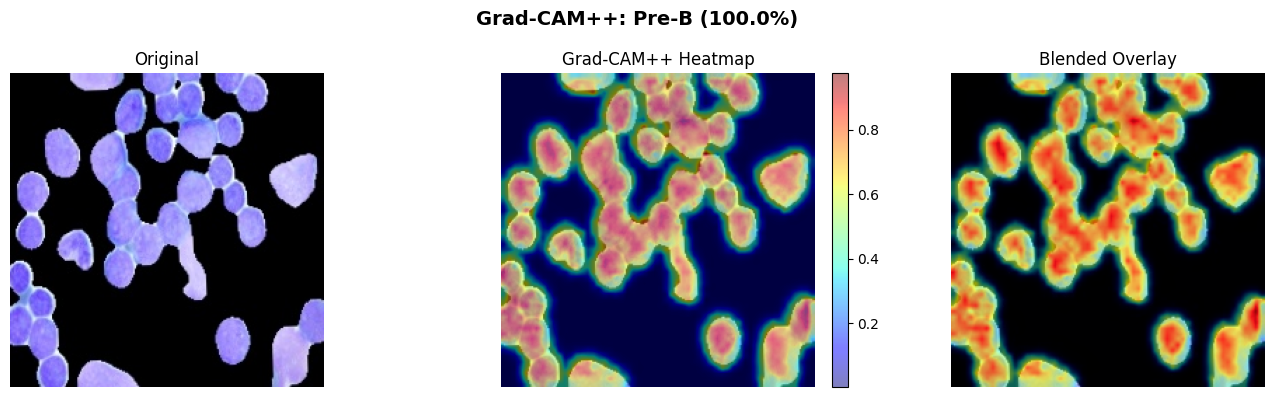

In [39]:
# ================= Example Usage =================
target_layer = 'activation_25'    #'conv2d_72'  
image = test_data[0][0][0]
print(image.shape)
explainer = GradCAMPlusPlus(model, target_layer, labels)
fig = explainer.visualize_gradcam_plus_plus(image)
plt.show()

✓ Grad-CAM++ initialized with layer: activation_25

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                  🔍  BASELINE DIAGNOSIS                
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  📷  Image 0  →  Predicted : Pre-B
  ──────────────────────────────────────────────────
  Confidence Type           Score   Note
  ──────────────────────────────────────────────────
  Original                 1.0000
  Blur baseline            0.9583   ← should be LOW
  Zero baseline            0.4499   ← should be LOW
  Mean baseline            0.0006   ← should be LOW
  ──────────────────────────────────────────────────
  Score Range              0.9994   ✅ OK

  📷  Image 1  →  Predicted : Pro-B
  ──────────────────────────────────────────────────
  Confidence Type           Score   Note
  ──────────────────────────────────────────────────
  Original                 1.0000
  Blur baseline            0.0114   ← should be LOW
  Zero baseline            0.0138   ← should

  Evaluating GradCAM++:  12%|█▏        | 3/25 [05:20<39:10, 106.83s/it]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                     📋  EVALUATION SUMMARY                    
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Images evaluated                  100
  Images skipped                      0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              📊  GradCAM++ STATISTICAL VALIDATION             
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Images (n)                       100
  Significance level (α)           0.05
  Most-used baseline               mean
  Avg original confidence          0.9906
  Avg baseline confidence          0.0021
  Avg score range                  0.9884
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌─ 🗑️  DELETION  AUC ───────────────────────────────────────
  │  ↓ below 0.5 = good  (removes important pixels first)
  │
  │  Mean ± SD                   0.0945 ± 0

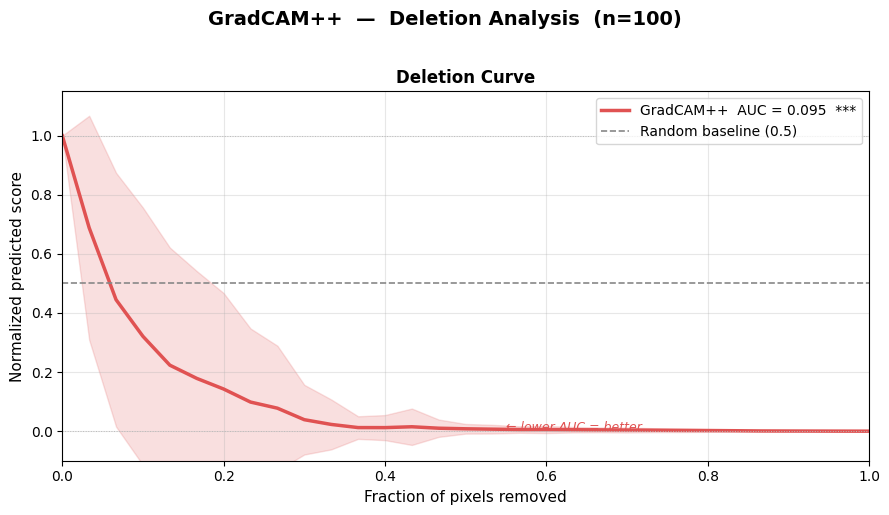

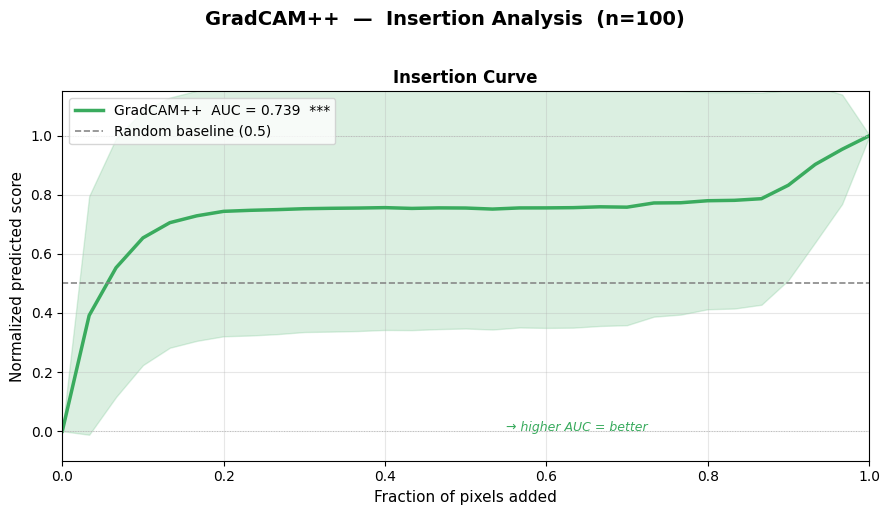

In [40]:
# ================================================================
#  HELPERS
# ================================================================
def ensure_float01(img):
    img = np.array(img, dtype=np.float32)
    return img / 255.0 if img.max() > 1.0 else img


def upsample_cam(cam, target_shape):
    cam = np.array(cam, dtype=np.float32)
    cam = np.squeeze(cam)
    if cam.ndim != 2:
        raise ValueError(f"CAM must be 2-D after squeeze, got shape {cam.shape}")
    cam_tf = tf.image.resize(
        cam[..., np.newaxis], target_shape[:2], method='bilinear'
    ).numpy()[..., 0]
    mn, mx = cam_tf.min(), cam_tf.max()
    return (cam_tf - mn) / (mx - mn + 1e-8) if mx > mn else np.zeros_like(cam_tf)


# ================================================================
#  BASELINE DIAGNOSIS
# ================================================================
def diagnose_baseline(model, test_iterator, labels, n=5):
    W = 55
    print(f"\n{'━'*W}")
    print(f"{'  🔍  BASELINE DIAGNOSIS':^{W}}")
    print(f"{'━'*W}")

    for b in range(min(n, len(test_iterator))):
        batch        = test_iterator[b]
        images_batch = batch[0] if isinstance(batch, (tuple, list)) else batch
        img          = ensure_float01(np.array(images_batch[0], dtype=np.float32))

        orig_s = model.predict(img[np.newaxis],                              verbose=0)[0]
        blur_s = model.predict(gaussian_filter(img, sigma=(21,21,0))[np.newaxis], verbose=0)[0]
        zero_s = model.predict(np.zeros_like(img)[np.newaxis],               verbose=0)[0]
        mean_s = model.predict(np.full_like(img, 0.5)[np.newaxis],           verbose=0)[0]

        pred_idx       = int(np.argmax(orig_s))
        best_base_conf = min(blur_s[pred_idx], zero_s[pred_idx], mean_s[pred_idx])
        score_range    = orig_s[pred_idx] - best_base_conf
        status         = "⚠️  OVERCONFIDENT" if score_range < 0.05 else "✅ OK"

        print(f"\n  📷  Image {b}  →  Predicted : \033[1m{labels[pred_idx]}\033[0m")
        print(f"  {'─'*50}")
        print(f"  {'Confidence Type':<22} {'Score':>8}   {'Note'}")
        print(f"  {'─'*50}")
        print(f"  {'Original':<22} {orig_s[pred_idx]:>8.4f}")
        print(f"  {'Blur baseline':<22} {blur_s[pred_idx]:>8.4f}   ← should be LOW")
        print(f"  {'Zero baseline':<22} {zero_s[pred_idx]:>8.4f}   ← should be LOW")
        print(f"  {'Mean baseline':<22} {mean_s[pred_idx]:>8.4f}   ← should be LOW")
        print(f"  {'─'*50}")
        print(f"  {'Score Range':<22} {score_range:>8.4f}   {status}")

    print(f"\n{'━'*W}\n")


# ================================================================
#  CORE METRIC — normalised deletion / insertion
# ================================================================
def deletion_insertion(model, image, cam, class_idx, steps=30, mode='deletion'):
    img     = ensure_float01(image)
    H, W, C = img.shape

    candidates = {
        'blur': gaussian_filter(img, sigma=(21, 21, 0)),
        'zero': np.zeros_like(img),
        'mean': np.full_like(img, 0.5),
    }
    base_confs = {
        name: float(model.predict(b[np.newaxis], verbose=0)[0][class_idx])
        for name, b in candidates.items()
    }
    best_name   = min(base_confs, key=base_confs.get)
    base        = candidates[best_name]
    base_conf   = base_confs[best_name]
    orig_conf   = float(model.predict(img[np.newaxis], verbose=0)[0][class_idx])
    score_range = orig_conf - base_conf

    order   = np.argsort(-cam.flatten())
    step_px = max(1, H * W // steps)
    raw     = []

    cur = img.copy() if mode == 'deletion' else base.copy()
    raw.append(float(model.predict(cur[np.newaxis], verbose=0)[0][class_idx]))

    for s in range(1, steps + 1):
        k      = min(s * step_px, H * W)
        idx    = order[:k]
        ys, xs = idx // W, idx % W
        if mode == 'deletion':
            cur[ys, xs, :] = base[ys, xs, :]
        else:
            cur[ys, xs, :] = img[ys, xs, :]
        raw.append(float(model.predict(cur[np.newaxis], verbose=0)[0][class_idx]))

    raw  = np.array(raw, dtype=np.float32)
    norm = (
        np.clip((raw - base_conf) / (score_range + 1e-8), -0.5, 1.5)
        if abs(score_range) > 1e-4
        else np.full_like(raw, 0.5)
    )
    auc = float(np.trapz(norm, np.linspace(0, 1, len(norm))))
    return norm, auc, best_name, orig_conf, base_conf


# ================================================================
#  STATISTICAL VALIDATION — GradCAM++ only
# ================================================================
def statistical_validation(
        test_iterator,
        gradcam_explainer,
        model,
        steps      = 30,
        max_images = None,
        alpha      = 0.05,
        plot       = True):

    def _get_cam(image):
        out = gradcam_explainer.predict_and_explain(image)
        for key in ('gradcam', 'cam', 'heatmap', 'saliency'):
            if key in out:
                return upsample_cam(np.array(out[key]), image.shape)
        for v in out.values():
            arr = np.array(v)
            if arr.ndim >= 2:
                return upsample_cam(arr, image.shape)
        raise ValueError(f"No usable heatmap found. Keys: {list(out.keys())}")

    records    = []
    flat_count = 0
    skip_count = 0

    for batch_idx in tqdm(range(len(test_iterator)), desc="  Evaluating GradCAM++"):
        batch        = test_iterator[batch_idx]
        images_batch = batch[0] if isinstance(batch, (tuple, list)) else batch

        for i in range(images_batch.shape[0]):
            img      = ensure_float01(np.array(images_batch[i], dtype=np.float32))
            preds    = model.predict(img[np.newaxis], verbose=0)[0]
            pred_idx = int(np.argmax(preds))

            if float(preds[pred_idx]) < 0.5:
                skip_count += 1
                continue

            try:
                cam = _get_cam(img)
            except Exception as e:
                print(f"\n  ⚠️  Skipping [{batch_idx}/{i}]: CAM error — {e}")
                skip_count += 1
                continue

            try:
                del_curve, del_auc, bl, oc, bc = deletion_insertion(
                    model, img, cam, pred_idx, steps, 'deletion')
                ins_curve, ins_auc, _,  _,  _  = deletion_insertion(
                    model, img, cam, pred_idx, steps, 'insertion')
            except Exception as e:
                print(f"\n  ⚠️  Skipping [{batch_idx}/{i}]: metric error — {e}")
                skip_count += 1
                continue

            if (oc - bc) < 1e-4:
                flat_count += 1

            records.append(dict(
                del_auc=del_auc, ins_auc=ins_auc,
                del_curve=del_curve, ins_curve=ins_curve,
                orig_conf=oc, base_conf=bc, baseline=bl,
            ))

            if max_images and len(records) >= max_images:
                break
        if max_images and len(records) >= max_images:
            break

    n = len(records)

    # ── summary banner ───────────────────────────────────────
    W = 62
    print(f"\n{'━'*W}")
    print(f"{'  📋  EVALUATION SUMMARY':^{W}}")
    print(f"{'━'*W}")
    print(f"  {'Images evaluated':<30} {n:>6}")
    print(f"  {'Images skipped':<30} {skip_count:>6}")
    if flat_count:
        print(f"  {'Flat-model images (AUC=0.5)':<30} {flat_count:>6}  ⚠️")
    print(f"{'━'*W}\n")

    if n < 2:
        print("  ❌  Not enough valid images evaluated.")
        return None

    # ── collect arrays ───────────────────────────────────────
    del_aucs = np.array([r['del_auc']   for r in records])
    ins_aucs = np.array([r['ins_auc']   for r in records])
    delta    = ins_aucs - del_aucs
    avg_orig = np.mean([r['orig_conf']  for r in records])
    avg_base = np.mean([r['base_conf']  for r in records])
    bl_names = [r['baseline']           for r in records]
    common_bl = max(set(bl_names), key=bl_names.count)

    # ── stats helper ─────────────────────────────────────────
    def run_tests(arr, label, higher_is_better=True):
        t_stat, t_p  = stats.ttest_1samp(arr, 0.5)
        try:
            w_stat, w_p = stats.wilcoxon(arr - 0.5)
        except Exception:
            w_stat, w_p = np.nan, np.nan

        ci        = stats.t.interval(0.95, df=n-1, loc=arr.mean(), scale=stats.sem(arr))
        arrow     = "↑" if higher_is_better else "↓"
        sig_t     = "✅ sig" if t_p < alpha else "❌ n.s."
        sig_w     = "✅ sig" if (not np.isnan(w_p) and w_p < alpha) else "❌ n.s."
        vs_random = ("✅ BETTER" if (higher_is_better and arr.mean() > 0.5)
                     or (not higher_is_better and arr.mean() < 0.5)
                     else "❌ WORSE")

        return dict(
            mean=float(arr.mean()), std=float(arr.std()),
            median=float(np.median(arr)),
            ci_low=float(ci[0]), ci_high=float(ci[1]),
            t_stat=float(t_stat), t_p=float(t_p),
            w_stat=w_stat, w_p=float(w_p),
            sig_t=sig_t, sig_w=sig_w, vs_random=vs_random, arrow=arrow
        )

    r_del   = run_tests(del_aucs, "Deletion  AUC", higher_is_better=False)
    r_ins   = run_tests(ins_aucs, "Insertion AUC", higher_is_better=True)
    r_delta = run_tests(delta,    "Δ Ins − Del",   higher_is_better=True)

    # ── pretty console output ────────────────────────────────
    W = 62
    print(f"{'━'*W}")
    print(f"{'  📊  GradCAM++ STATISTICAL VALIDATION':^{W}}")
    print(f"{'━'*W}")
    print(f"  {'Images (n)':<32} {n}")
    print(f"  {'Significance level (α)':<32} {alpha}")
    print(f"  {'Most-used baseline':<32} {common_bl}")
    print(f"  {'Avg original confidence':<32} {avg_orig:.4f}")
    print(f"  {'Avg baseline confidence':<32} {avg_base:.4f}")
    print(f"  {'Avg score range':<32} {avg_orig - avg_base:.4f}")
    print(f"{'━'*W}")

    for r, title, hint in [
        (r_del,   "🗑️  DELETION  AUC",   "↓ below 0.5 = good  (removes important pixels first)"),
        (r_ins,   "➕  INSERTION AUC",   "↑ above 0.5 = good  (adds important pixels first)"),
        (r_delta, "📐  Δ  INS − DEL",    "↑ above 0.0 = good  (overall faithfulness proxy)"),
    ]:
        print(f"\n  ┌─ {title} {'─'*(W-6-len(title))}")
        print(f"  │  {hint}")
        print(f"  │")
        print(f"  │  {'Mean ± SD':<26}  {r['mean']:.4f} ± {r['std']:.4f}")
        print(f"  │  {'Median':<26}  {r['median']:.4f}")
        print(f"  │  {'95% CI':<26}  [{r['ci_low']:.4f},  {r['ci_high']:.4f}]")
        print(f"  │")
        print(f"  │  {'Paired t-test (vs 0.5)':<26}  t = {r['t_stat']:+.3f},  p = {r['t_p']:.4f}  →  {r['sig_t']}")
        print(f"  │  {'Wilcoxon (vs 0.5)':<26}  W = {r['w_stat']},  p = {r['w_p']:.4f}  →  {r['sig_w']}")
        print(f"  │")
        print(f"  └─ vs Random Baseline :  {r['vs_random']}")

    print(f"\n{'━'*W}")
    print(f"{'  🎯  VERDICT':^{W}}")
    print(f"{'━'*W}")
    print(f"  {'Metric':<20} {'Value':>8}   {'Result'}")
    print(f"  {'─'*48}")
    del_ok  = r_del['mean']   < 0.5
    ins_ok  = r_ins['mean']   > 0.5
    dlt_ok  = r_delta['mean'] > 0.0
    print(f"  {'Deletion  AUC':<20} {r_del['mean']:>8.4f}   {'✅ < 0.5  — focused saliency' if del_ok else '❌ ≥ 0.5  — unfocused'}")
    print(f"  {'Insertion AUC':<20} {r_ins['mean']:>8.4f}   {'✅ > 0.5  — fast recovery'    if ins_ok else '❌ ≤ 0.5  — slow recovery'}")
    print(f"  {'Δ Ins − Del':<20} {r_delta['mean']:>8.4f}   {'✅ > 0.0  — faithful'          if dlt_ok else '❌ ≤ 0.0  — unfaithful'}")
    overall = sum([del_ok, ins_ok, dlt_ok])
    grade   = {3: "🏆 EXCELLENT", 2: "👍 GOOD", 1: "⚠️  MARGINAL", 0: "❌ POOR"}[overall]
    print(f"  {'─'*48}")
    print(f"  Overall GradCAM++ Quality :  {grade}  ({overall}/3 criteria met)")
    print(f"{'━'*W}\n")

    # ── plots: 2 separate figures ────────────────────────────
    # if plot:
    #     max_len = max(len(r['del_curve']) for r in records)

    #     def pad(curves):
    #         return np.array([np.pad(c, (0, max_len - len(c)), 'edge') for c in curves])

    #     del_m = np.mean(pad([r['del_curve'] for r in records]), axis=0)
    #     del_s = np.std( pad([r['del_curve'] for r in records]), axis=0)
    #     ins_m = np.mean(pad([r['ins_curve'] for r in records]), axis=0)
    #     ins_s = np.std( pad([r['ins_curve'] for r in records]), axis=0)
    #     xs    = np.linspace(0, 1, max_len)

    #     def sig_star(p):
    #         if   p < 0.001: return '***'
    #         elif p < 0.01:  return '**'
    #         elif p < 0.05:  return '*'
    #         else:           return 'n.s.'

    #     # ── Figure 1 : Deletion ──────────────────────────────
    #     fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
    #     fig1.suptitle(
    #         f'GradCAM++  —  Deletion Analysis  (n={n})',
    #         fontsize=14, fontweight='bold', y=1.02
    #     )

    #     # Left: deletion curve
    #     ax = axes1[0]
    #     ax.plot(xs, del_m, color='#e05252', lw=2.5,
    #             label=f'GradCAM++  AUC = {r_del["mean"]:.3f}  {sig_star(r_del["t_p"])}')
    #     ax.fill_between(xs, del_m - del_s, del_m + del_s, alpha=0.18, color='#e05252')
    #     ax.axhline(0.5, color='#888', lw=1.2, ls='--', label='Random baseline (0.5)')
    #     ax.axhline(0,   color='#bbb', lw=0.7, ls=':')
    #     ax.axhline(1,   color='#bbb', lw=0.7, ls=':')
    #     ax.set_title('Deletion Curve', fontweight='bold', fontsize=12)
    #     ax.set_xlabel('Fraction of pixels removed', fontsize=11)
    #     ax.set_ylabel('Normalised predicted score', fontsize=11)
    #     ax.set_xlim(0, 1); ax.set_ylim(-0.1, 1.15)
    #     ax.legend(fontsize=10); ax.grid(alpha=0.3)
    #     ax.annotate('← lower AUC = better', xy=(0.55, 0.08),
    #                 xycoords='axes fraction', fontsize=9, color='#e05252',
    #                 style='italic')

    #     # Right: deletion boxplot + bar
    #     ax = axes1[1]
    #     bp = ax.boxplot([del_aucs], patch_artist=True,
    #                     medianprops=dict(color='black', linewidth=2), widths=0.4)
    #     bp['boxes'][0].set_facecolor('#e05252'); bp['boxes'][0].set_alpha(0.7)
    #     ax.axhline(0.5, color='#888', lw=1.2, ls='--', label='0.5 (random)')
    #     ax.set_xticks([1]); ax.set_xticklabels(['Deletion AUC'], fontsize=11)
    #     ax.set_title('Distribution', fontweight='bold', fontsize=12)
    #     ax.set_ylabel('AUC', fontsize=11)
    #     y_top = del_aucs.max() * 1.08
    #     ax.text(1, y_top, sig_star(r_del['t_p']),
    #             ha='center', va='bottom', fontsize=13, fontweight='bold')
    #     ax.text(1, del_aucs.min() * 0.96,
    #             f"mean={r_del['mean']:.3f}\nSD={r_del['std']:.3f}",
    #             ha='center', va='top', fontsize=9, color='#555')
    #     ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    #     plt.tight_layout()
    #     plt.show()

    #     # ── Figure 2 : Insertion ─────────────────────────────
    #     fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    #     fig2.suptitle(
    #         f'GradCAM++  —  Insertion Analysis  (n={n})',
    #         fontsize=14, fontweight='bold', y=1.02
    #     )

    #     # Left: insertion curve
    #     ax = axes2[0]
    #     ax.plot(xs, ins_m, color='#3aab5e', lw=2.5,
    #             label=f'GradCAM++  AUC = {r_ins["mean"]:.3f}  {sig_star(r_ins["t_p"])}')
    #     ax.fill_between(xs, ins_m - ins_s, ins_m + ins_s, alpha=0.18, color='#3aab5e')
    #     ax.axhline(0.5, color='#888', lw=1.2, ls='--', label='Random baseline (0.5)')
    #     ax.axhline(0,   color='#bbb', lw=0.7, ls=':')
    #     ax.axhline(1,   color='#bbb', lw=0.7, ls=':')
    #     ax.set_title('Insertion Curve', fontweight='bold', fontsize=12)
    #     ax.set_xlabel('Fraction of pixels added', fontsize=11)
    #     ax.set_ylabel('Normalised predicted score', fontsize=11)
    #     ax.set_xlim(0, 1); ax.set_ylim(-0.1, 1.15)
    #     ax.legend(fontsize=10); ax.grid(alpha=0.3)
    #     ax.annotate('→ higher AUC = better', xy=(0.55, 0.08),
    #                 xycoords='axes fraction', fontsize=9, color='#3aab5e',
    #                 style='italic')

    #     # Right: insertion boxplot
    #     ax = axes2[1]
    #     bp = ax.boxplot([ins_aucs], patch_artist=True,
    #                     medianprops=dict(color='black', linewidth=2), widths=0.4)
    #     bp['boxes'][0].set_facecolor('#3aab5e'); bp['boxes'][0].set_alpha(0.7)
    #     ax.axhline(0.5, color='#888', lw=1.2, ls='--', label='0.5 (random)')
    #     ax.set_xticks([1]); ax.set_xticklabels(['Insertion AUC'], fontsize=11)
    #     ax.set_title('Distribution', fontweight='bold', fontsize=12)
    #     ax.set_ylabel('AUC', fontsize=11)
    #     y_top = ins_aucs.max() * 1.08
    #     ax.text(1, y_top, sig_star(r_ins['t_p']),
    #             ha='center', va='bottom', fontsize=13, fontweight='bold')
    #     ax.text(1, ins_aucs.min() * 0.96,
    #             f"mean={r_ins['mean']:.3f}\nSD={r_ins['std']:.3f}",
    #             ha='center', va='top', fontsize=9, color='#555')
    #     ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    #     plt.tight_layout()
    #     plt.show()
    if plot:
        max_len = max(len(r['del_curve']) for r in records)

        def pad(curves):
            return np.array([np.pad(c, (0, max_len - len(c)), 'edge') for c in curves])

        del_m = np.mean(pad([r['del_curve'] for r in records]), axis=0)
        del_s = np.std( pad([r['del_curve'] for r in records]), axis=0)
        ins_m = np.mean(pad([r['ins_curve'] for r in records]), axis=0)
        ins_s = np.std( pad([r['ins_curve'] for r in records]), axis=0)
        xs    = np.linspace(0, 1, max_len)

        def sig_star(p):
            if   p < 0.001: return '***'
            elif p < 0.01:  return '**'
            elif p < 0.05:  return '*'
            else:           return 'n.s.'

        # ── Figure 1 : Deletion Curve ────────────────────────
        fig1, ax = plt.subplots(figsize=(9, 5))
        fig1.suptitle(
            f'GradCAM++  —  Deletion Analysis  (n={n})',
            fontsize=14, fontweight='bold', y=1.02
        )
        ax.plot(xs, del_m, color='#e05252', lw=2.5,
                label=f'GradCAM++  AUC = {r_del["mean"]:.3f}  {sig_star(r_del["t_p"])}')
        ax.fill_between(xs, del_m - del_s, del_m + del_s, alpha=0.18, color='#e05252')
        ax.axhline(0.5, color='#888', lw=1.2, ls='--', label='Random baseline (0.5)')
        ax.axhline(0,   color='#bbb', lw=0.7, ls=':')
        ax.axhline(1,   color='#bbb', lw=0.7, ls=':')
        ax.set_title('Deletion Curve', fontweight='bold', fontsize=12)
        ax.set_xlabel('Fraction of pixels removed', fontsize=11)
        ax.set_ylabel('Normalized predicted score', fontsize=11)
        ax.set_xlim(0, 1); ax.set_ylim(-0.1, 1.15)
        ax.legend(fontsize=10); ax.grid(alpha=0.3)
        ax.annotate('← lower AUC = better', xy=(0.55, 0.08),
                    xycoords='axes fraction', fontsize=9, color='#e05252', style='italic')
        plt.tight_layout()
        plt.show()

        # ── Figure 2 : Insertion Curve ───────────────────────
        fig2, ax = plt.subplots(figsize=(9, 5))
        fig2.suptitle(
            f'GradCAM++  —  Insertion Analysis  (n={n})',
            fontsize=14, fontweight='bold', y=1.02
        )
        ax.plot(xs, ins_m, color='#3aab5e', lw=2.5,
                label=f'GradCAM++  AUC = {r_ins["mean"]:.3f}  {sig_star(r_ins["t_p"])}')
        ax.fill_between(xs, ins_m - ins_s, ins_m + ins_s, alpha=0.18, color='#3aab5e')
        ax.axhline(0.5, color='#888', lw=1.2, ls='--', label='Random baseline (0.5)')
        ax.axhline(0,   color='#bbb', lw=0.7, ls=':')
        ax.axhline(1,   color='#bbb', lw=0.7, ls=':')
        ax.set_title('Insertion Curve', fontweight='bold', fontsize=12)
        ax.set_xlabel('Fraction of pixels added', fontsize=11)
        ax.set_ylabel('Normalized predicted score', fontsize=11)
        ax.set_xlim(0, 1); ax.set_ylim(-0.1, 1.15)
        ax.legend(fontsize=10); ax.grid(alpha=0.3)
        ax.annotate('→ higher AUC = better', xy=(0.55, 0.08),
                    xycoords='axes fraction', fontsize=9, color='#3aab5e', style='italic')
        plt.tight_layout()
        plt.show()

    return dict(
        n_images  = n,
        deletion  = r_del,
        insertion = r_ins,
        delta     = r_delta,
        raw       = dict(del_aucs=del_aucs, ins_aucs=ins_aucs, delta=delta),
    )


# ================================================================
#  RUN
# ================================================================
gradcam_explainer = GradCAMPlusPlus(model, 'activation_25', labels)

# Step 1 — diagnose
diagnose_baseline(model, test_data, labels, n=5)

# Step 2 — validate
summary = statistical_validation(
    test_iterator     = test_data,
    gradcam_explainer = gradcam_explainer,
    model             = model,
    steps             = 30,
    max_images        = 100,
    alpha             = 0.05,
    plot              = True,
)